# Landing Analysis

In [ ]:
# Imports and Configs
import os
import tomllib
import json
from datetime import date
from pathlib import Path
from importlib import  reload

# Add the parent directory to the system path
import sys
sys.path.append(os.path.abspath('..'))

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
notebook_dir = Path.cwd()
config_path = notebook_dir.parent / "config.toml"
PROJECT_ROOT = config_path.parent.parent
with config_path.open('rb') as f:
    config = tomllib.load(f)

REF_PATH            = PROJECT_ROOT / Path(config["db_path"]["REF_PATH"])
RESULTS_DIR         = PROJECT_ROOT / Path(config["output"]["RESULTS_DIR"])

In [ ]:
# Set your CSV_PATH or use the default one
CSV_PATH            = PROJECT_ROOT / Path(config['input']['CSV_PATH'])
# CSV_PATH = Path(r"C:\Users\Fardad\Desktop\Briefing\PG\26.08.25\Tacview-20260825-194431-DCS-Host-IQT-2 26-08-25-V1.csv")
print(f"CSV_PATH: {CSV_PATH}")

CSV_PATH: C:\Users\Fardad\Desktop\Briefing\PG\26.08.25\Tacview-20260825-194431-DCS-Host-IQT-2 26-08-25-V1.csv


In [2]:
# Make the output directory
record_date, mission_name = extract_date_name_tacview(CSV_PATH)
if record_date is None:
    record_date = date.today().strftime("%Y%m%d")

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

print(f"record_date: {record_date}")

record_date: 20260825


## 1. Load DB once

In [10]:
import src.data_loaders
import src.transformer_plotter
import src.geographic_calculations
reload(src.data_loaders)
reload(src.transformer_plotter)
reload(src.geographic_calculations)
from src.data_loaders import load_runway_db, read_telemetry_csv
from src.transformer_plotter import transform_telemetry, touchdown_discovery
from src.geographic_calculations import bearing_true

In [3]:
# 1. Load DB
runway_db = load_runway_db(REF_PATH)
runway_db[runway_db['icao_code'] == 'PGUA'].iloc[[0,2]]

Runway DB loaded successfully.


,airport_name,iata_code,icao_code,runway_name,lat,lon,heading_T
31910,Andersen Air Force Base,UAM,PGUA,06L,13.5803,144.916000,66.0
80052,Andersen Air Force Base,UAM,PGUA,24R,13.5922,144.942993,246.0


## 2. Touchdown Discovery

In [11]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

Successfully read CSV file: C:\Users\Fardad\Desktop\Briefing\PG\26.08.25\Tacview-20260825-194431-DCS-Host-IQT-2 26-08-25-V1.csv
Pilots: ['T55-1', 'T55-2', 'T55-3', 'T55-1-1', 'T55-1-2', 'T55-1-3', 'T55-2-1', 'T55-2-2', 'T55-2-3', 'T55-3-1', 'T55-3-2', 'T55-3-3', 'T55-4-1', 'T55-4-2', 'T55-4-3', 'T55-5-1', 'T55-5-2', 'T55-5-3', 'T55-6-1', 'T55-6-2', 'T55-6-3', 'T55-7-1', 'T55-7-2', 'T55-7-3', 'T55-8-1', 'T55-8-2', 'T55-8-3', 'T55-9-1', 'T55-9-2', 'T55-9-3', 'Ground-11-1', 'Ground-9-1', 'Aerial-1-2', 'Aerial-2-1', 'Aerial-3-1', 'Aerial-3-2', 'Aerial-5-1', 'Aerial-4-1', 'Ground-2-1', 'MELMI-25-1', 'QSM-1-1', 'DAVEP-1', 'MELMI-31-1', 'Ground-1-1', 'VOR-BND-1', 'VOR-SYZ-1', 'AWACS-1', 'QSM-1-2', '< 404C > IR.shadow', '< 404C >Cooper', '< 404C > F.U.B.A.R', '< 404C > LCDR vici', '< 404C > Eclipse', '< 404C > Rough14', '<404C> Aryan', '< 404 > A D L E R', nan]

Successfully selected 75482 rows of data.
Selected Pilots: ['< 404C > Eclipse', '< 404C > Rough14', '< 404C >Cooper', '<404C> Aryan',

## 3. CSS-Stylized Results Table

In [12]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

Exported styled HTML.
Exported table image.


Sortie,Touchdown Time,Aircraft,Pilot,CAS (kt),VS (fpm),heading_true,Airport,Runway,Touchdown to Threshold (ft)
1,2020-08-05 03:58:47.594919,F-16C_50,< 404C > F.U.B.A.R,168,-464,210,OIKB,21L,1195
1,2020-08-05 03:58:54.894912,F-16C_50,< 404C > LCDR vici,146,-538,211,OIKB,21L,2058
1,2020-08-05 04:08:42.694352,F-16C_50,< 404C > IR.shadow,147,-701,211,OIKB,21L,899
1,2020-08-05 04:10:28.794251,F-16C_50,< 404C >Cooper,158,-640,210,OIKB,21L,1615
1,2020-08-05 04:12:20.894144,F-16C_50,<404C> Aryan,171,-1738,224,OIKB,21L,716
1,2020-08-05 04:18:09.493811,F-16C_50,< 404C > Eclipse,147,-348,210,OIKB,21L,3385
1,2020-08-05 04:20:20.393686,F-16C_50,< 404C > Rough14,141,-309,209,OIKB,21L,3613
2,2020-08-05 04:21:05.093644,F-16C_50,<404C> Aryan,151,-258,210,OIKB,21L,3006
2,2020-08-05 05:08:41.190920,F-16C_50,< 404C > IR.shadow,151,-963,211,OIKB,21L,2355


## 4. Plot Approach Profiles

Here are all landing profiles:


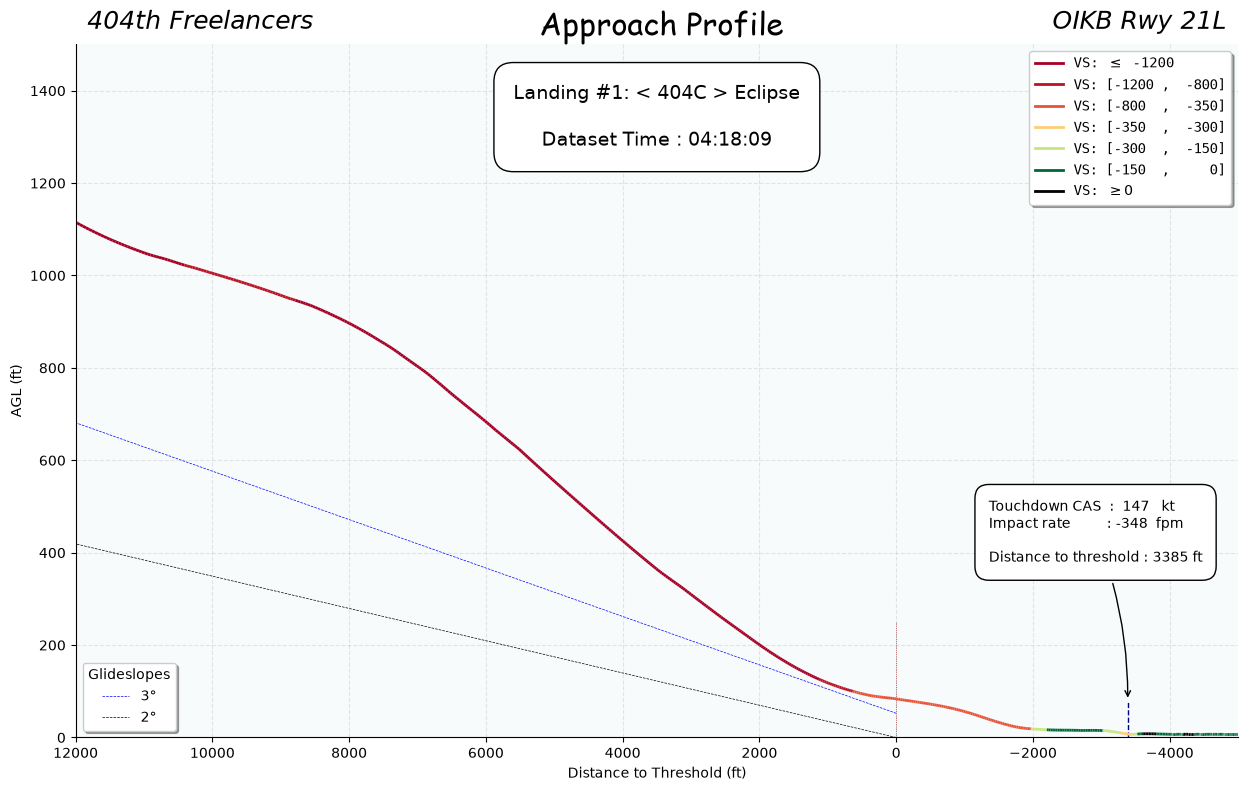

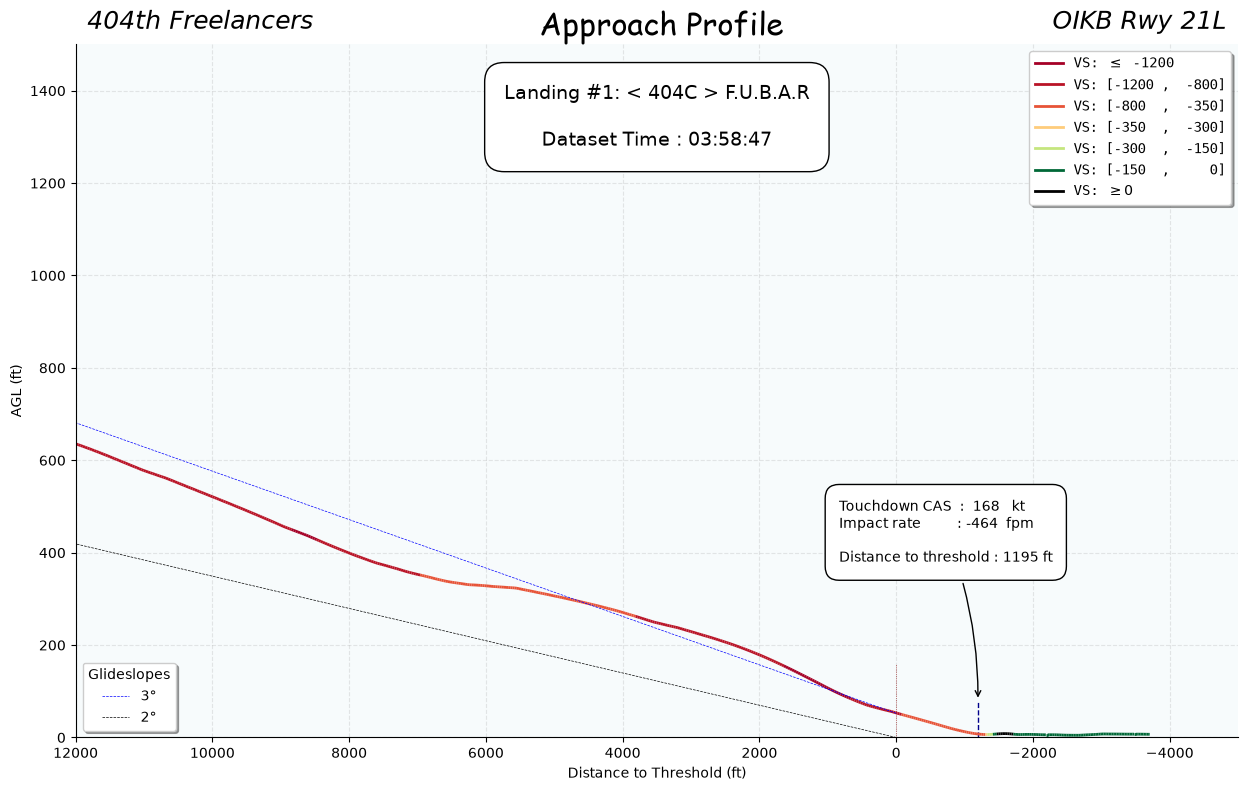

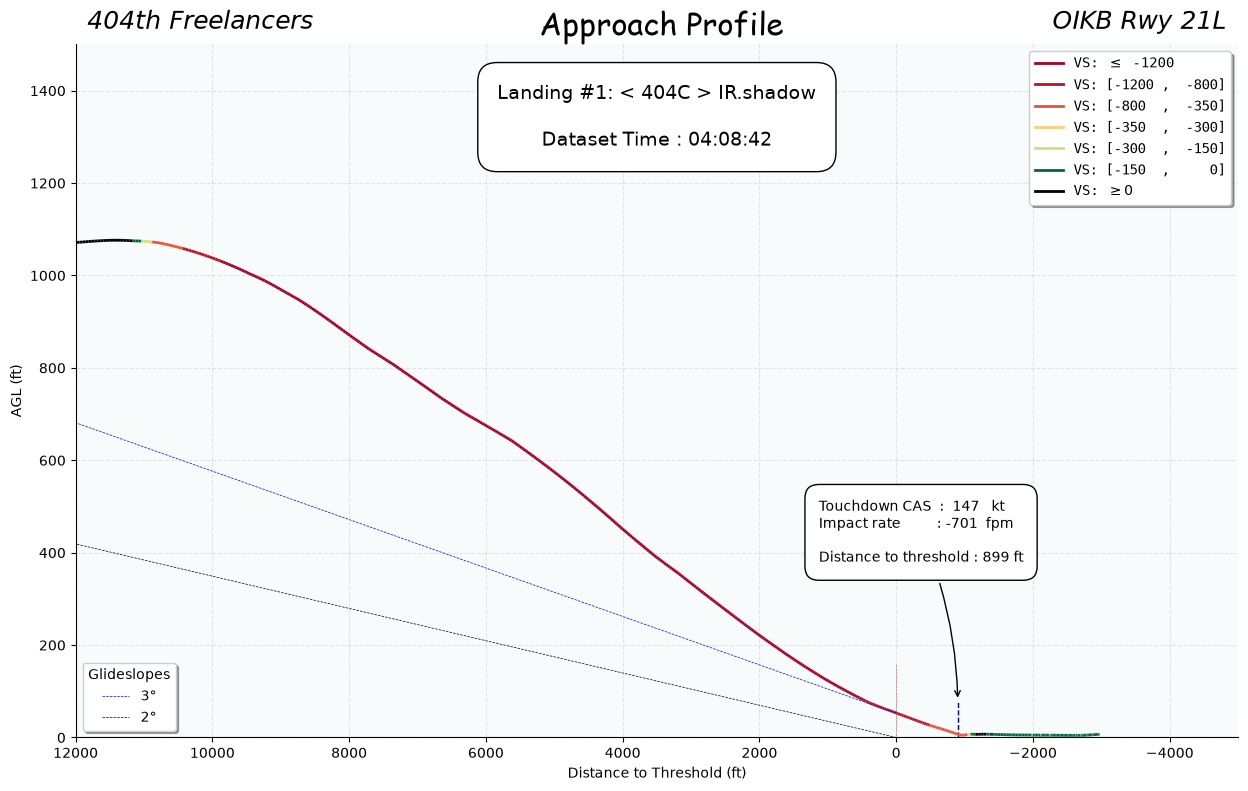

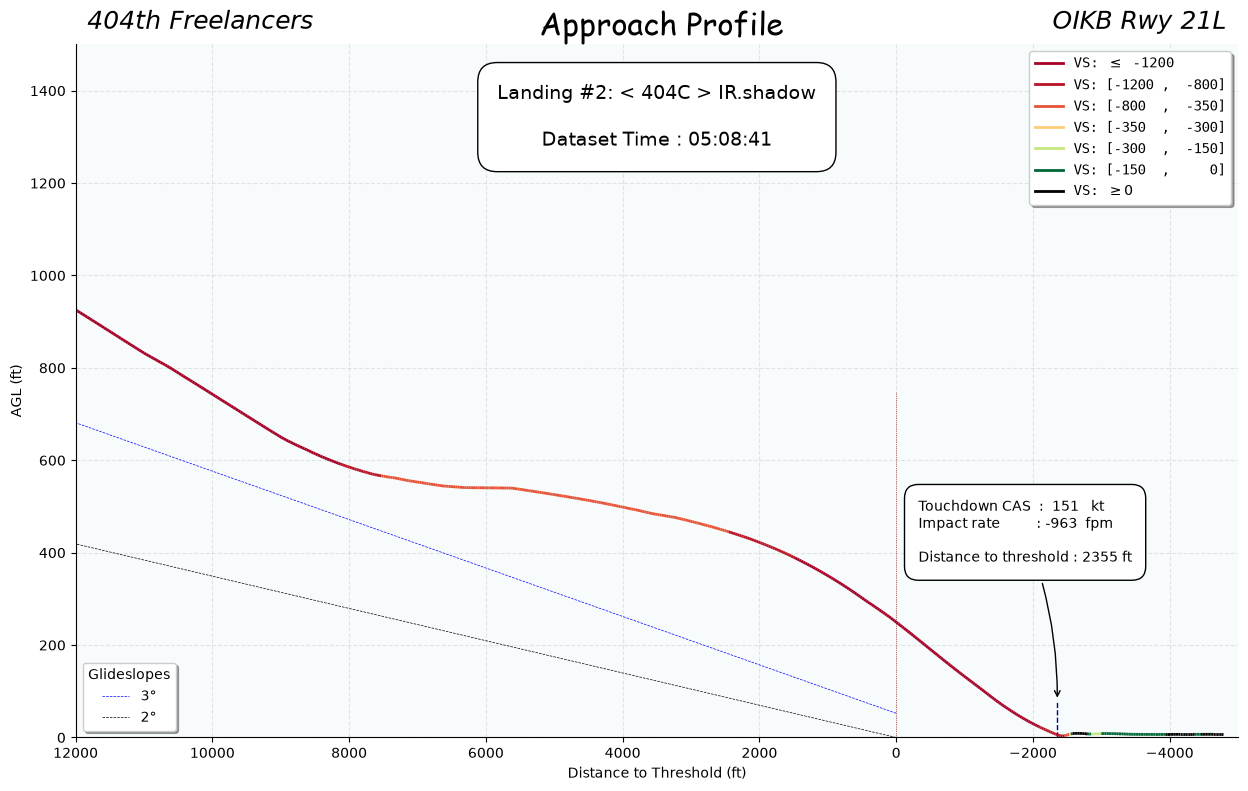

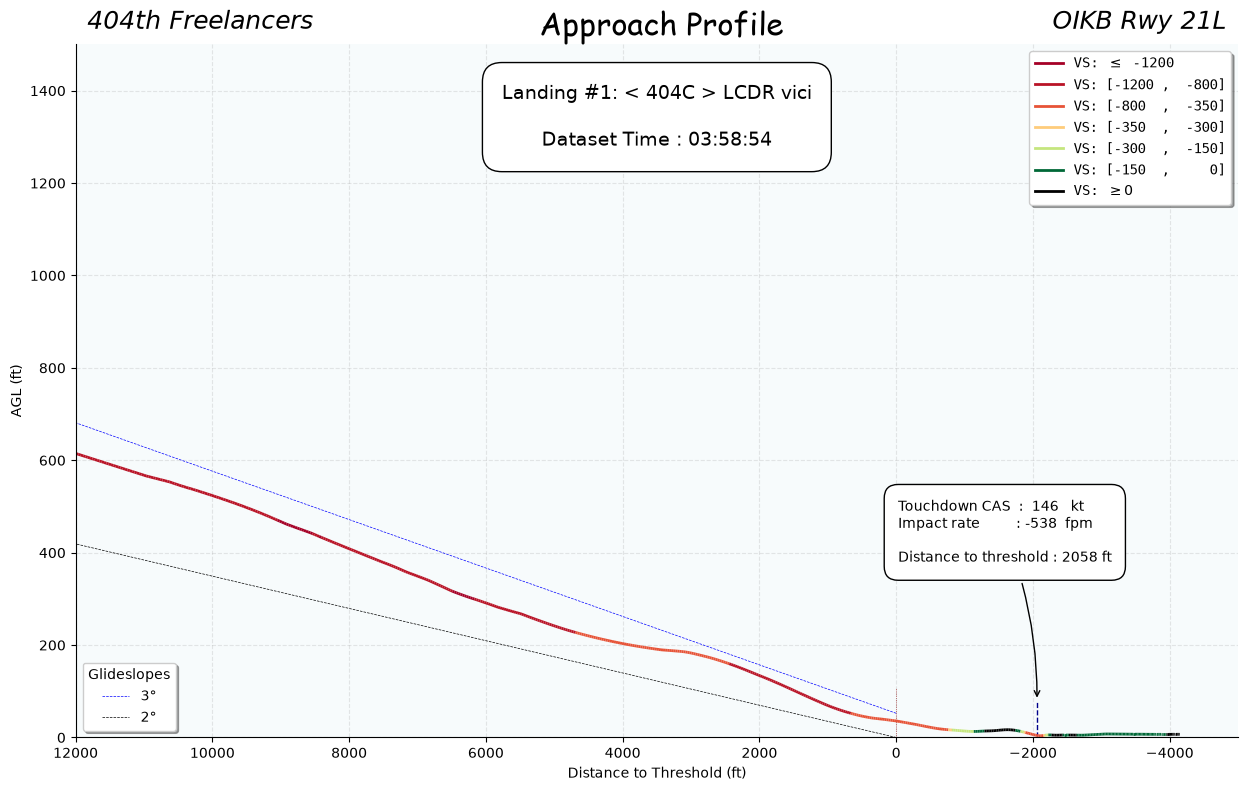

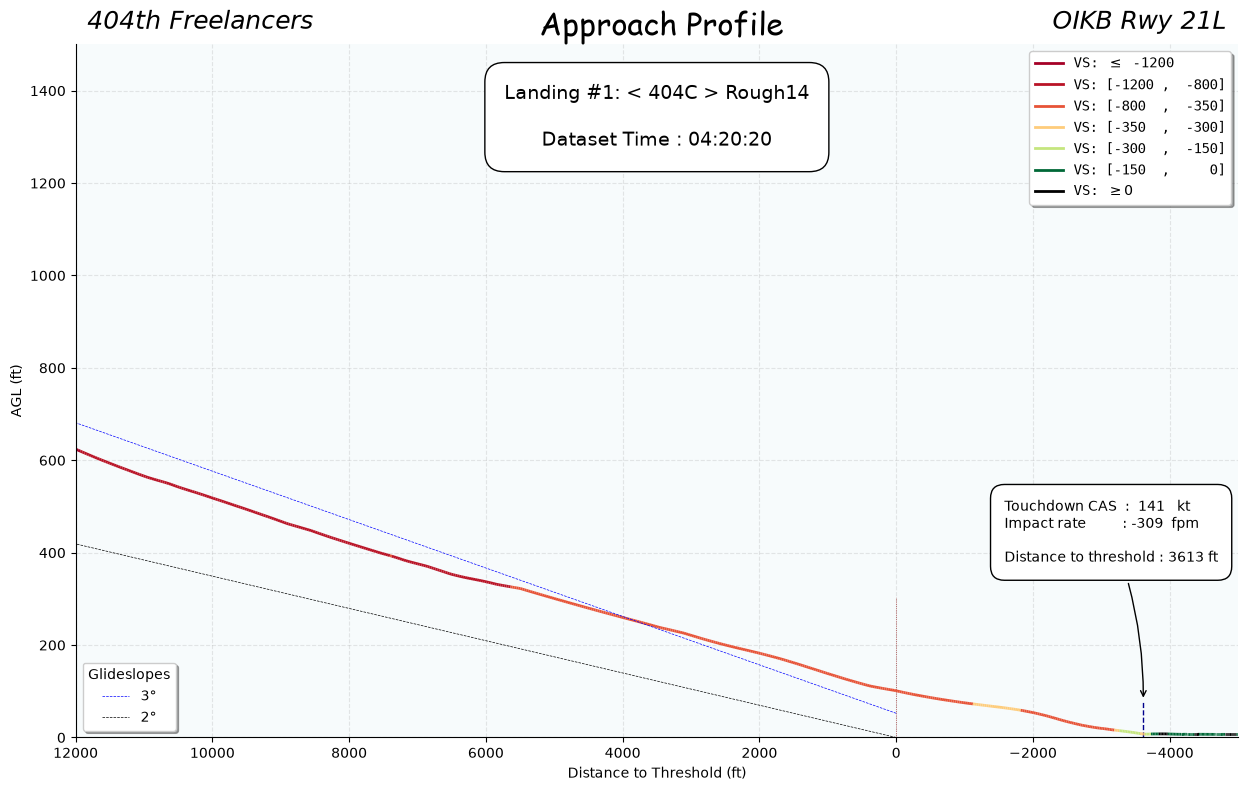

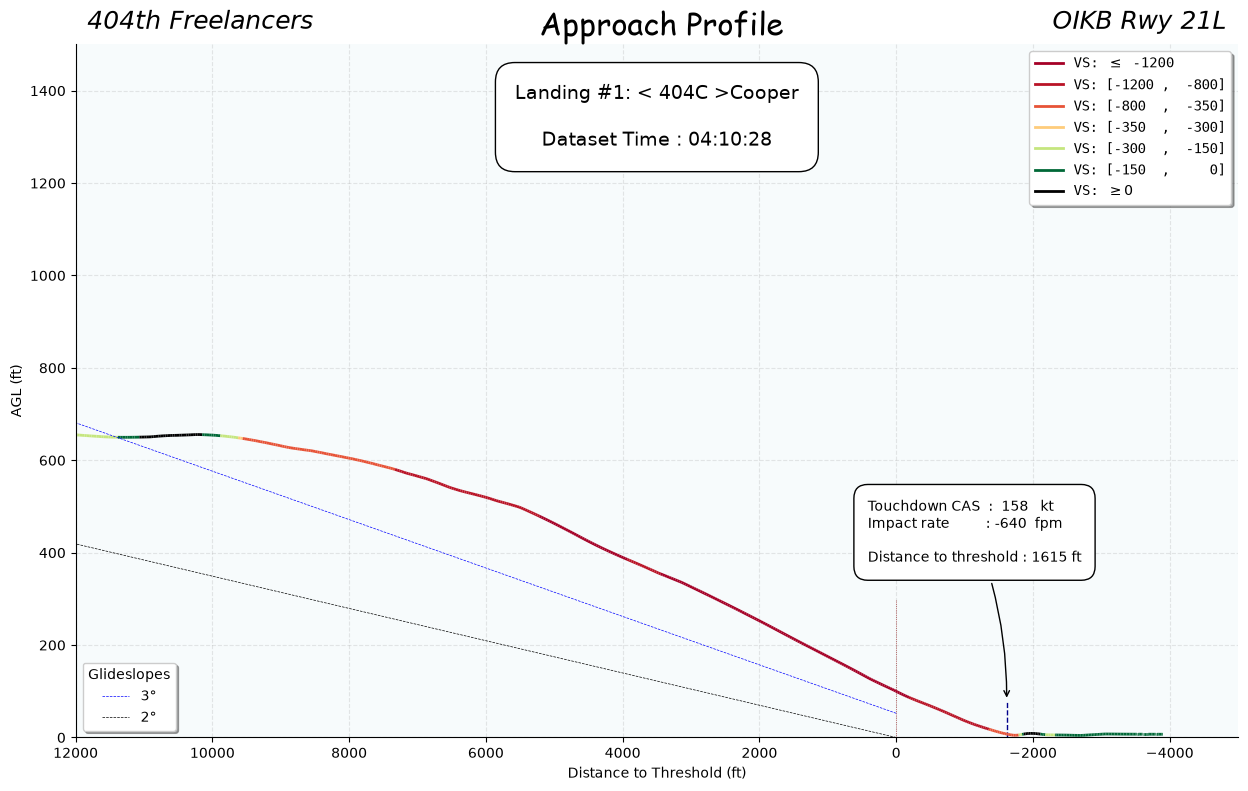

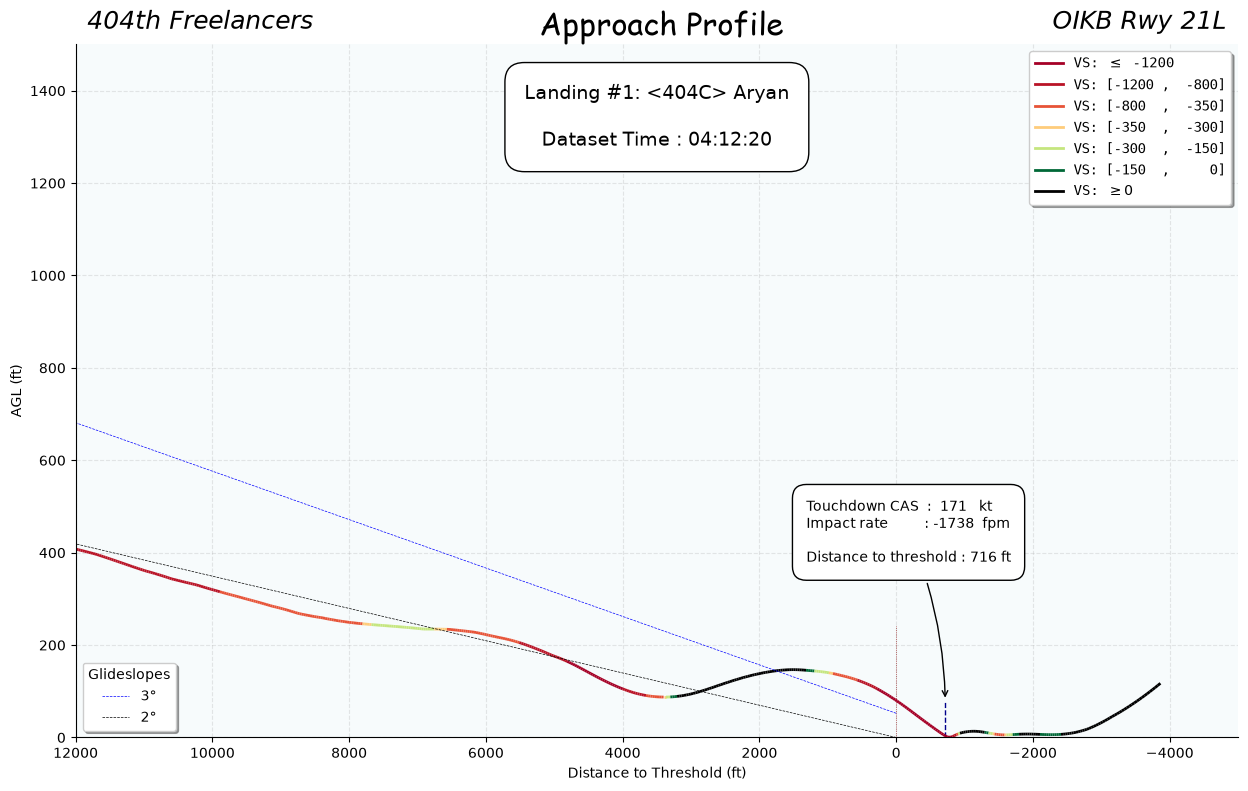

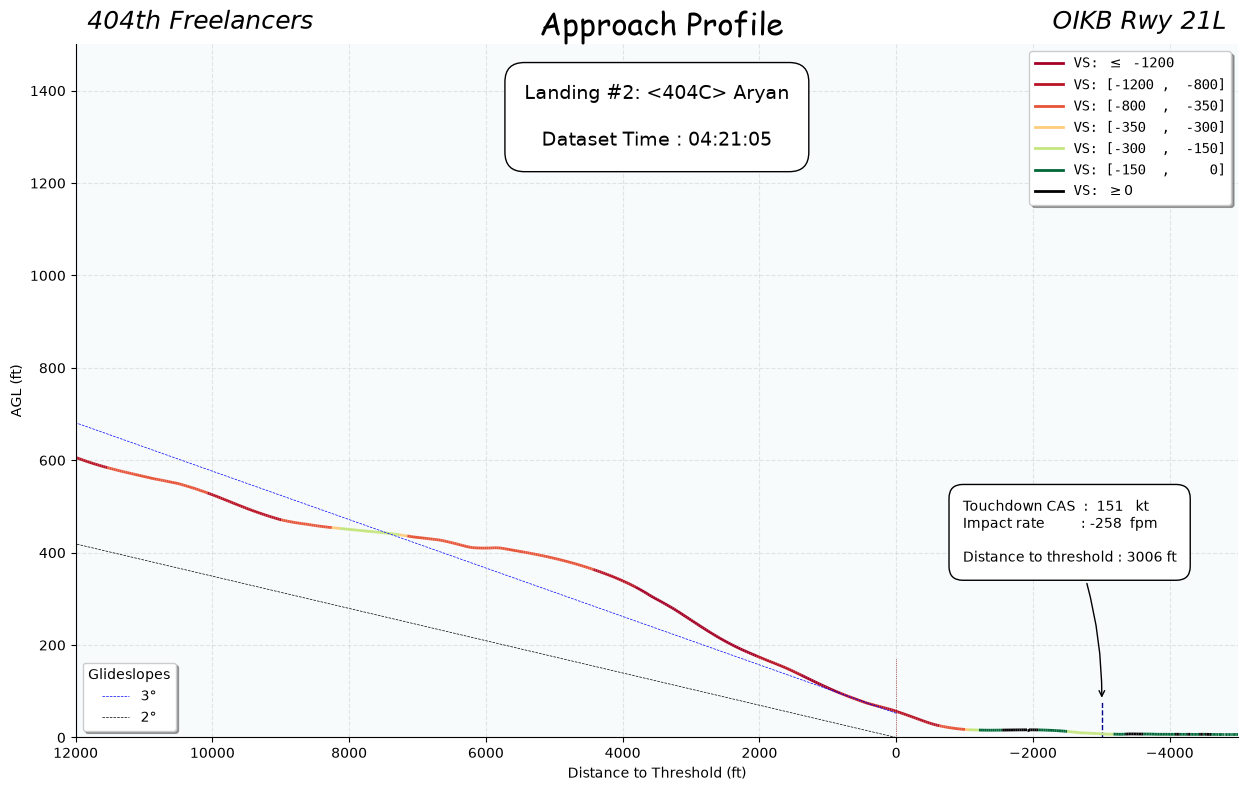

In [7]:
# 3. Plot/Export Profiles
for pilot in df_result['Pilot'].sort_values().unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        is_sortie = plot_landing_profile(df_sub, df_result, pilot, sortie_num, 
                                        plots_output_path, record_date, 
                                        close_fig = False)

print("Here are all landing profiles:")

## 5. Detailed Touchdowns (optional)

In [60]:
import src.transformer_plotter
reload(src.transformer_plotter)
from src.transformer_plotter import touchdown_plotter


c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\backend\src\transformer_plotter.py:74: SyntaxWarning: invalid escape sequence '\l'
  labels = [f'$\leq$ {thresholds[1]}']
c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\backend\src\transformer_plotter.py:79: SyntaxWarning: invalid escape sequence '\g'
  labels.append(  f'$\geq 0$'  )


Sortie #4 of < 404C > Phoenix Took less than 6 second!
All Touchdowns Plotted!


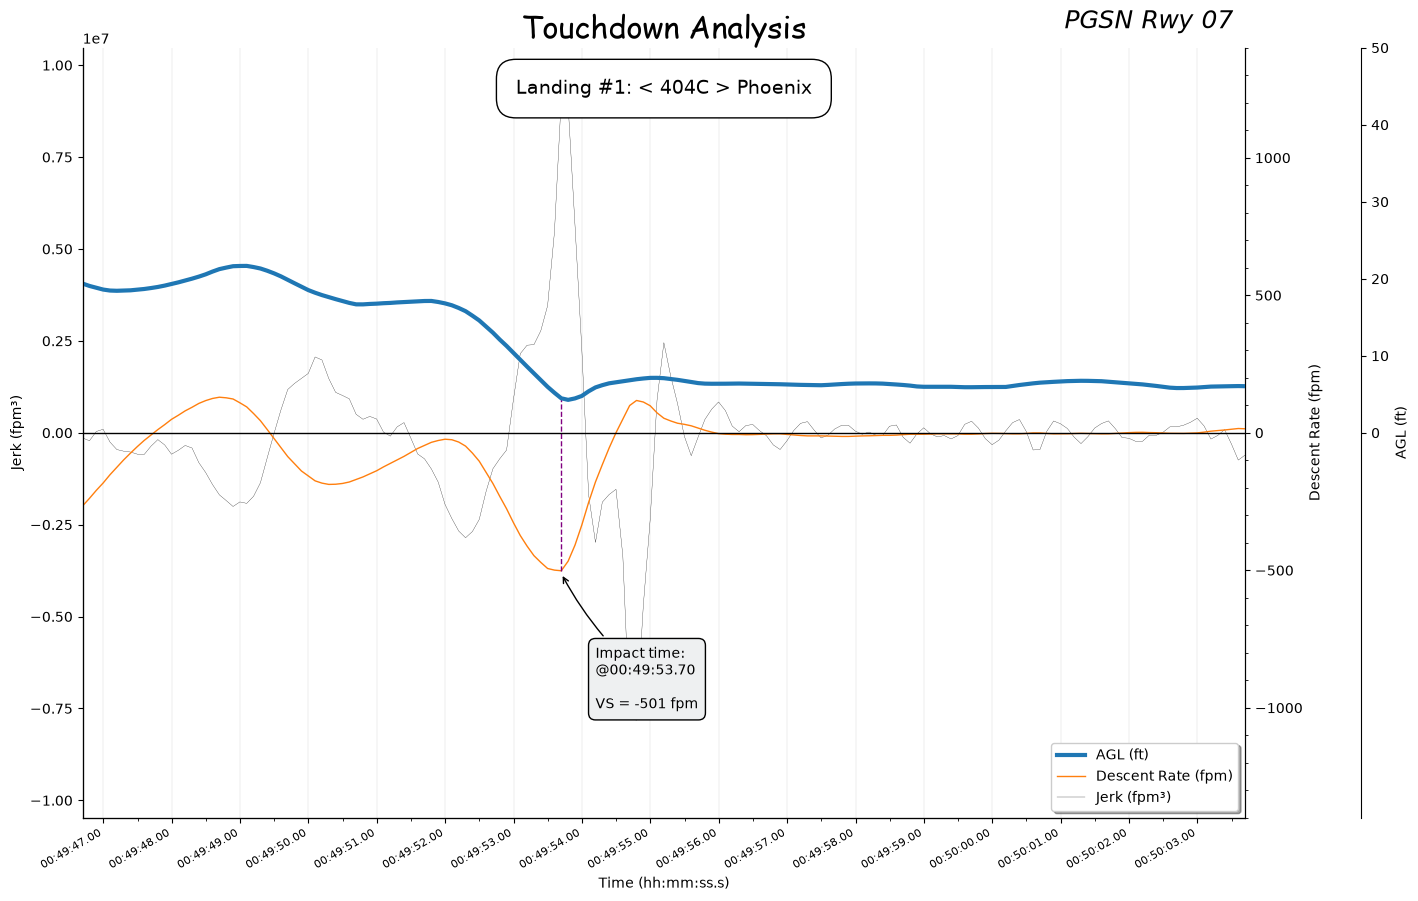

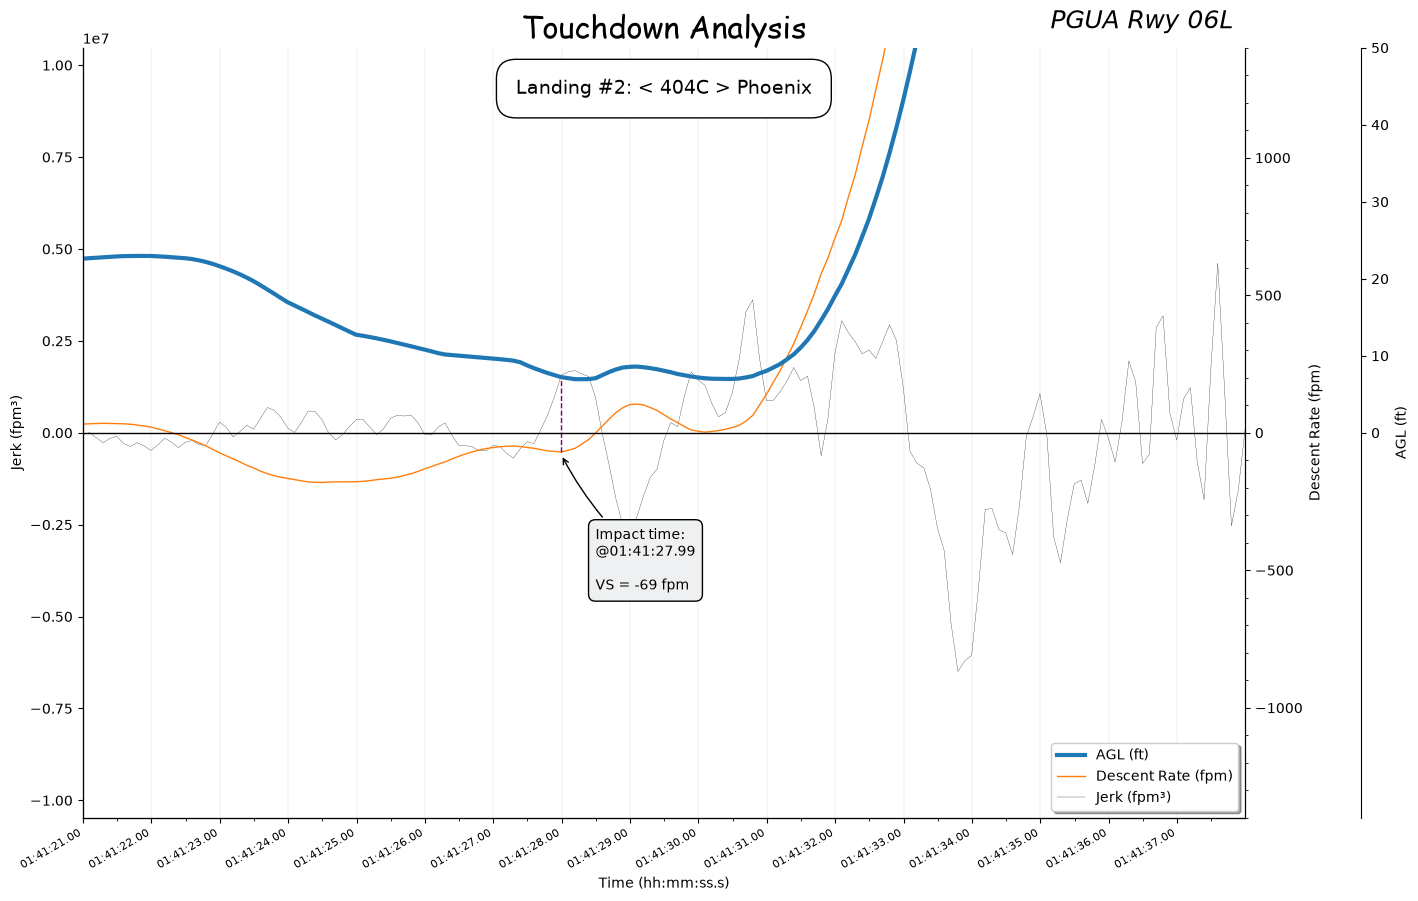

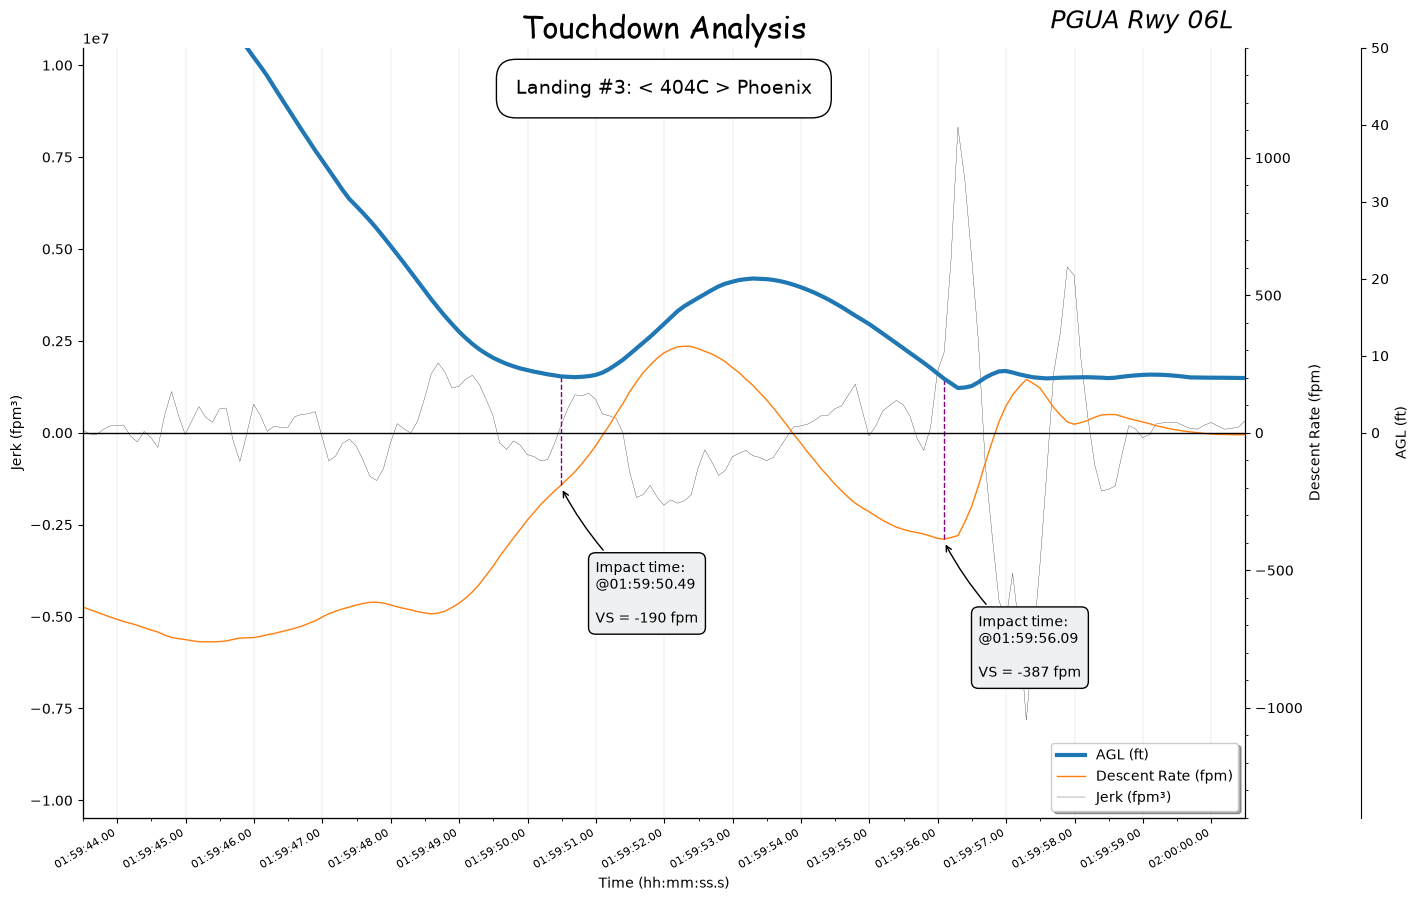

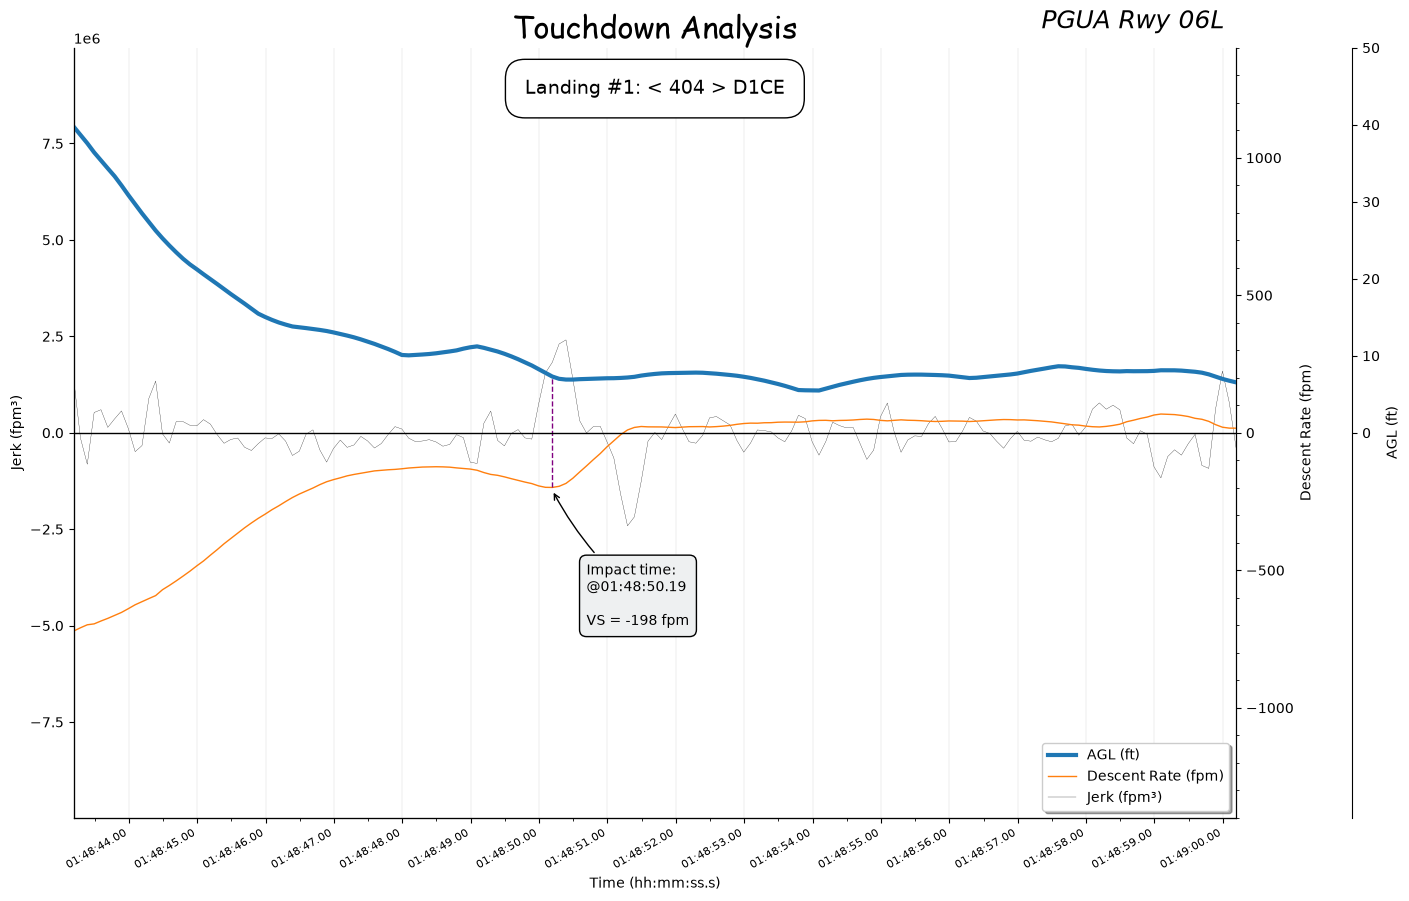

In [ ]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, 
                        detailed_td_path, record_date, 
                        close_fig = False)

print("All Touchdowns Plots:")